In [1]:
# load libraries

import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import PIL
import requests

In [2]:
# load data

tips = sns.load_dataset("tips")
print(tips) 

     total_bill   tip     sex smoker   day    time  size
0         16.99  1.01  Female     No   Sun  Dinner     2
1         10.34  1.66    Male     No   Sun  Dinner     3
2         21.01  3.50    Male     No   Sun  Dinner     3
3         23.68  3.31    Male     No   Sun  Dinner     2
4         24.59  3.61  Female     No   Sun  Dinner     4
..          ...   ...     ...    ...   ...     ...   ...
239       29.03  5.92    Male     No   Sat  Dinner     3
240       27.18  2.00  Female    Yes   Sat  Dinner     2
241       22.67  2.00    Male    Yes   Sat  Dinner     2
242       17.82  1.75    Male     No   Sat  Dinner     2
243       18.78  3.00  Female     No  Thur  Dinner     2

[244 rows x 7 columns]


<Axes: xlabel='total_bill', ylabel='tip'>

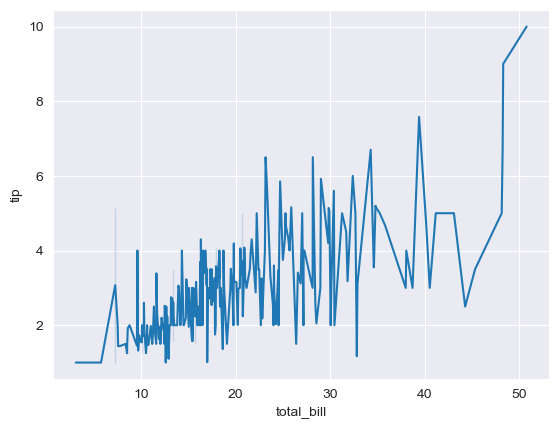

In [7]:
# sns.set_style("whitegrid") # adds a grid to the plot with white background and gray gridlines
sns.set_style("darkgrid") # this adds dark gray background with white gridlines

sns.lineplot(data=tips, x="total_bill", y="tip")

[Text(0.5, 1.0, 'Tip vs Total Bill'),
 Text(0.5, 0, 'Total Bill ($)'),
 Text(0, 0.5, 'Tip Amount ($)')]

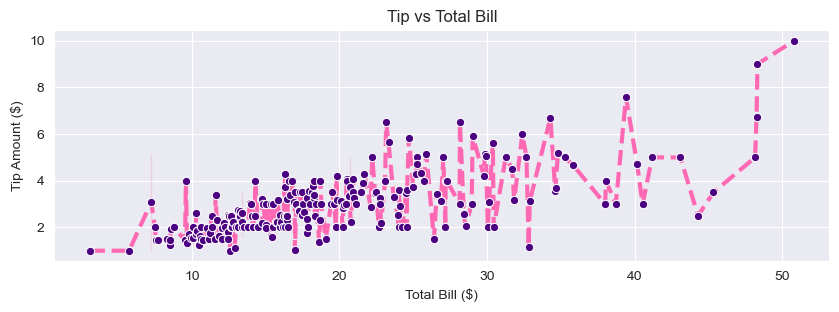

In [10]:
fig = plt.subplots(figsize = (10,3))

tipgraph = sns.lineplot(data=tips, x="total_bill", y="tip",
                        color = "hotpink",
                        linestyle = "--",
                        linewidth = 3,
                        marker = "o",
                        markerfacecolor = "indigo")

tipgraph.set(title = "Tip vs Total Bill",
             xlabel = "Total Bill ($)",
             ylabel = "Tip Amount ($)")

[Text(0.5, 1.0, 'Tips vs Total Bill'),
 Text(0.5, 0, 'Total Bill ($)'),
 Text(0, 0.5, 'Tip Amount ($)')]

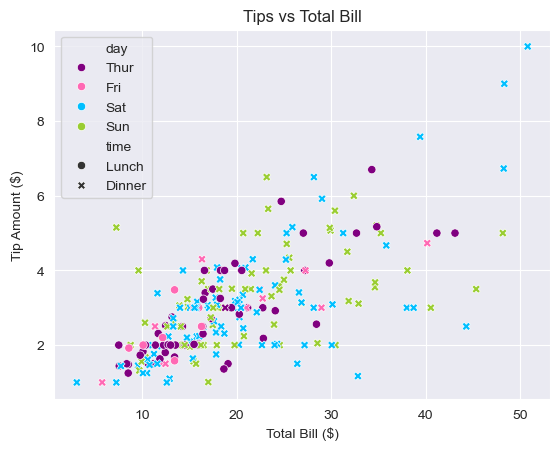

In [11]:
tipgraph = sns.scatterplot(data=tips, x="total_bill", y="tip",
                           # we want the style to change depending on time of meal, and hue to change dependent on time of day
                           style = "time", hue="day",
                           palette=["purple", "hotpink", "deepskyblue", "yellowgreen"]) 

tipgraph.set(title= "Tips vs Total Bill",
             xlabel = "Total Bill ($)",
             ylabel = "Tip Amount ($)")

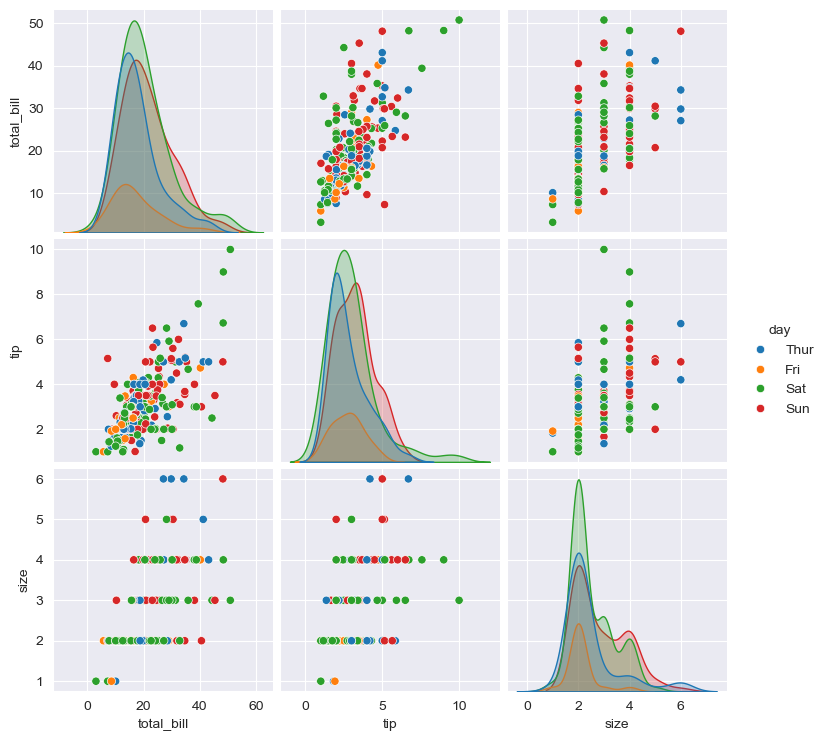

In [12]:
sns.pairplot(data=tips, hue="day") # can use this to do exploratory analysis to see what our data looks like

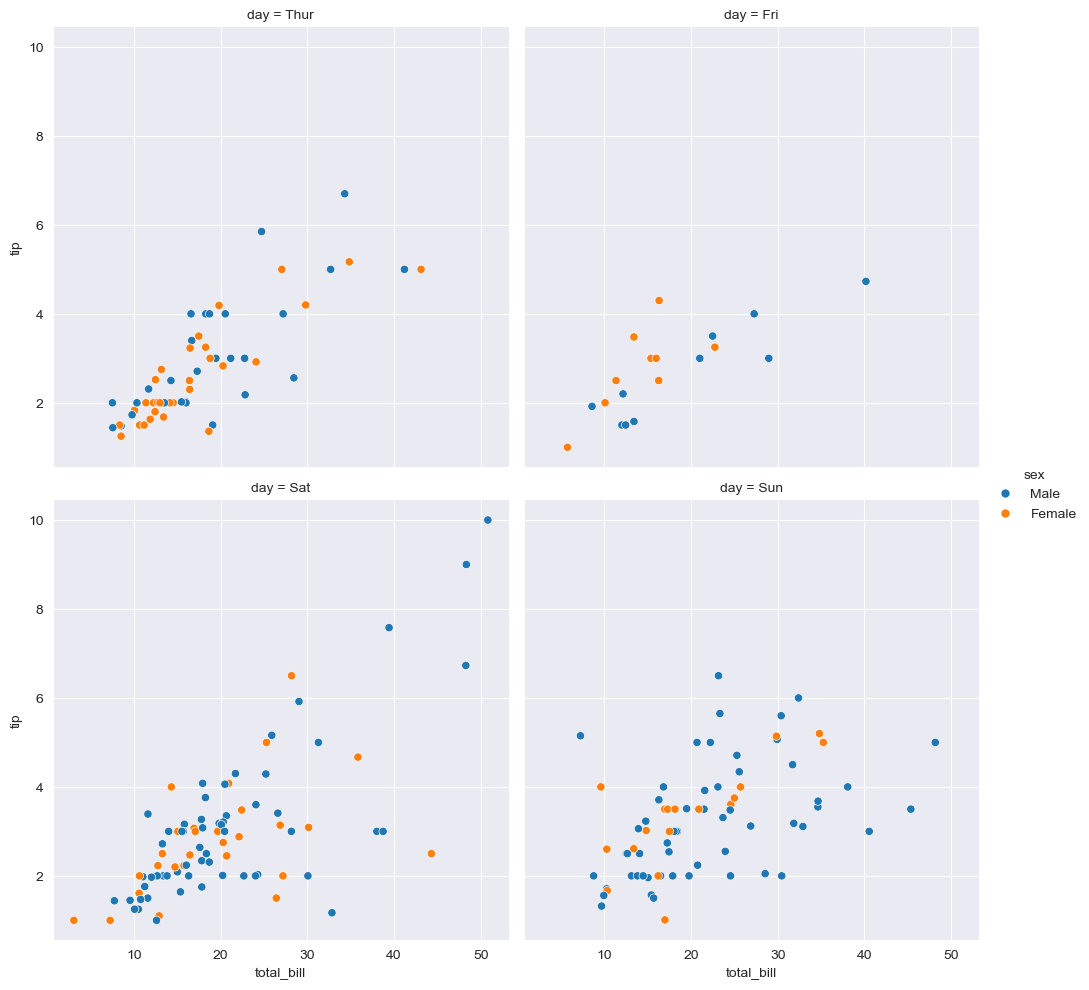

In [14]:
daysplot = sns.relplot(data = tips, x="total_bill", y="tip",
                       # want data to be bifurcated by day
                       hue = "sex", col="day",
                       kind="scatter", col_wrap=2)

In [ ]:
# install packages 
!pip install wordcloud
!pip install matplotlib-venn

In [19]:
# load libraries

import plotly.graph_objects as go # go as in graph objects
from wordcloud import WordCloud
from matplotlib_venn import venn2, venn2_circles, venn2_unweighted

In [22]:
# load data
x1 = np.array(["Luffy", "Zoro", "Nami", "Usopp", "Sanji"])
y1 = np.array([110, 180, 240, 99, 220])

In [25]:
graph = go.Figure()
graph.add_trace(go.Bar(x=x1, y=y1))

graph.update_layout(
    title="Pirate Scores",
    xaxis_title = "Pirates",
    yaxis_title="Score"
)

In [ ]:
graph = go.Figure()

graph.add_trace(go.Scatter(x=x1, y=y1, mode="markers",
                           marker=dict(
                               # size of dots/points
                               size = 15, 
                               color = "hotpink",
                               opacity = 1,
                               line=dict(width=5,
                                         color="purple")
                           )))

graph.update_layout(
    title="Interactive Pirate Plot",
    xaxis_title = "Pirates",
    yaxis_title = "Scores",
    width=500, height =500 # defining size of figure
)

In [28]:
# wordclouds

df = pd.read_csv("https://raw.githubusercontent.com/prasertcbs/basic-dataset/master/movie_quotes.csv", 
                 on_bad_lines="skip") # on_bad_lines will skip if it encounters any rows of data that has more columns than expected

df

,quote,movie,type,year
0,"Do, or do not. There is no try.",Star Wars: Episode V - The Empire Strikes Back,movie,1890
1,Listen to them. Children of the night. What mu...,Dracula,movie,1931
2,It's alive! It's alive!,Frankenstein,movie,1931
3,"Oh, no, it wasn't the airplanes. It was Beauty...",King Kong,movie,1933
4,"Magic Mirror on the wall, who is the fairest o...",Snow White and the Seven Dwarves,movie,1937
...,...,...,...,...
727,I didn't know if you were lost. Stick with me....,Us,movie,2019
728,This guy's awesome! He's holding his own while...,Dragon Ball Super: Broly,movie,2019
729,"Murder is murder, it don’t matter who you are.",Black and Blue,movie,2019
730,You know what a lion is? A lion is a strong an...,Between Two Ferns: The Movie,movie,2019


(-0.5, 399.5, 199.5, -0.5)

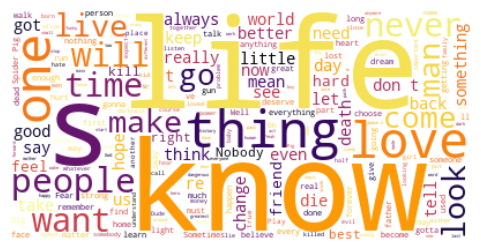

In [31]:
text= " ".join(each for each in df.quote)

wordcloud = WordCloud(background_color="white", 
                      colormap = "inferno").generate(text)

fig, ax=plt.subplots(figsize = (7,3))
ax.imshow(wordcloud, interpolation="bilinear")
ax.axis("off")

In [32]:
# making venn diagrams

A = set(["apple", "banana", "watermelon"])
B = set(["pumpkin", "blueberry", "apple", "key lime"])

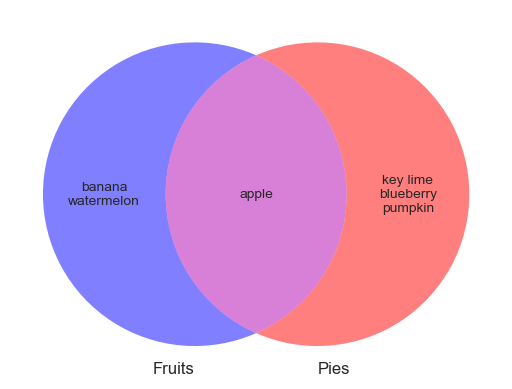

In [37]:
diagram = venn2_unweighted([A, B],
                           set_labels = ("Fruits", "Pies"), 
                           set_colors=("blue", "red"),
                           alpha = 0.5)

diagram.get_label_by_id("10").set_text("\n".join(A-B))
diagram.get_label_by_id("11").set_text("\n".join(A&B))
diagram.get_label_by_id("01").set_text("\n".join(B-A))